In [2]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


In [27]:
import pandas as pd
import numpy as np

#plotting library
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Models
from catboost import CatBoostClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
dataset=pd.read_csv("wheat_seed_variety.csv")

In [5]:
dataset.head()

,soil_type,region,water_source,irrigation_source,season,sown,sowing_window,soil_ph,temp,waterrequired,relative_humidity,n,p,k,cropduration,seed_variety
0,silt loam,Potohar,irrigated,rainfed,rabi,Oct,early,6.2,22.1,636.8,57.6,118.9,51.5,47.9,80.4,Arooj-22
1,silt loam,Canal Area,rainfed,mixed,rabi,Nov,optimal,6.1,23.4,480.0,53.0,115.6,55.0,58.4,82.5,Dilkash-20
2,silt loam,South Punjab,irrigated,canal,rabi,Dec,late,6.8,21.7,579.6,55.8,82.2,45.4,47.3,89.5,Sawera-24
3,silt loam,Canal Area,rainfed,mixed,rabi,Oct,early,6.4,21.4,566.5,51.6,102.7,55.5,45.3,84.6,Dilkash-20
4,silt loam,Canal Area,irrigated,rainfed,rabi,Nov,optimal,6.2,21.4,593.5,59.0,99.4,55.5,50.7,83.4,Dilkash-20


In [6]:
#before dropping shape
dataset.shape

(999, 16)

In [7]:
dataset.columns

Index(['soil_type', 'region', 'water_source', 'irrigation_source', 'season',
       'sown', 'sowing_window', 'soil_ph', 'temp', 'waterrequired',
       'relative_humidity', 'n', 'p', 'k', 'cropduration', 'seed_variety'],
      dtype='object')

In [8]:
#checking null values

dataset.isnull().sum()

,0
soil_type,0
region,0
water_source,0
irrigation_source,0
season,0
sown,0
sowing_window,0
soil_ph,0
temp,0
waterrequired,0


In [9]:
# checking duplicates
sum(dataset.duplicated())

0

In [10]:
#dataset info
print(dataset.info())
print(dataset.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   soil_type          999 non-null    object 
 1   region             999 non-null    object 
 2   water_source       999 non-null    object 
 3   irrigation_source  999 non-null    object 
 4   season             999 non-null    object 
 5   sown               999 non-null    object 
 6   sowing_window      999 non-null    object 
 7   soil_ph            999 non-null    float64
 8   temp               999 non-null    float64
 9   waterrequired      999 non-null    float64
 10  relative_humidity  999 non-null    float64
 11  n                  999 non-null    float64
 12  p                  999 non-null    float64
 13  k                  999 non-null    float64
 14  cropduration       999 non-null    float64
 15  seed_variety       999 non-null    object 
dtypes: float64(8), object(8)
m

In [11]:
#dropping columns
dropped_columns=["water_source","season","sowing_window","waterrequired","cropduration", "relative_humidity", "n", "p", "k"]
dataset=dataset.drop(dropped_columns, axis=1)

In [12]:
#updated shape
dataset.shape

(999, 7)

In [13]:
dataset_columns=dataset.columns
print(dataset_columns)

Index(['soil_type', 'region', 'irrigation_source', 'sown', 'soil_ph', 'temp',
       'seed_variety'],
      dtype='object')


In [15]:
# defining columns
categorical_cols = [
    'soil_type',
    'region',
    'irrigation_source',
    'sown'
]

numerical_cols = [
    'soil_ph',
    'temp'
]

target_col = 'seed_variety'

In [16]:
for col in categorical_cols:
  print(dataset[col].value_counts())

soil_type
loamy         266
clay loam     255
sandy loam    246
silt loam     232
Name: count, dtype: int64
region
Punjab North      210
Potohar           205
Canal Area        204
South Punjab      190
Central Punjab    190
Name: count, dtype: int64
irrigation_source
canal        260
tube well    259
mixed        252
rainfed      228
Name: count, dtype: int64
sown
Oct    333
Nov    333
Dec    333
Name: count, dtype: int64


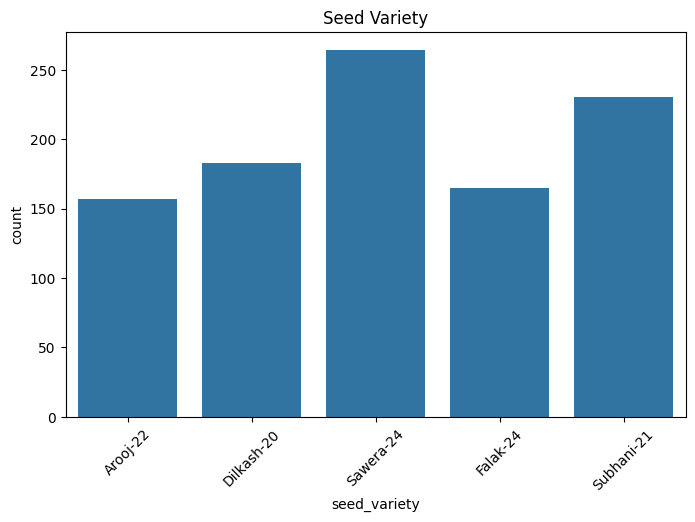

In [17]:
#plotting output columns

plt.figure(figsize=(8,5))
sns.countplot(x=dataset[target_col])
plt.title('Seed Variety')
plt.xticks(rotation=45)
plt.show()

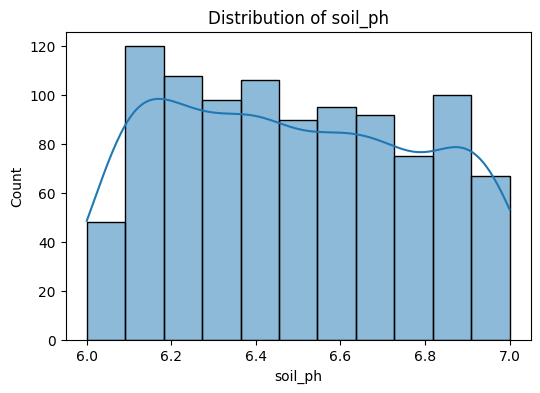

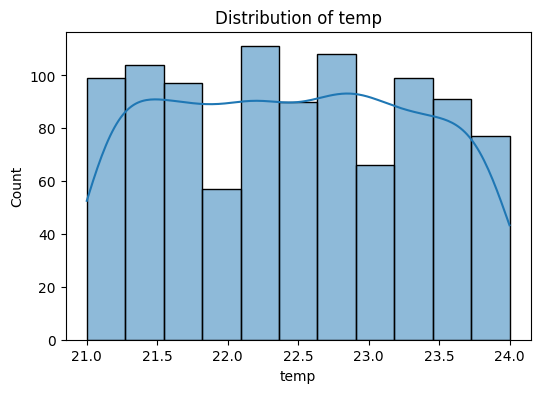

In [18]:
#checking distribution of input numerical columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

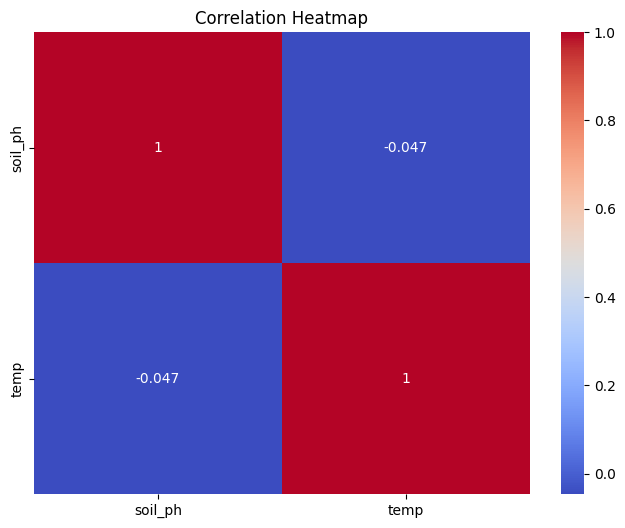

In [19]:
#checking correlation between numerical values

plt.figure(figsize=(8,6))

sns.heatmap(
    dataset[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

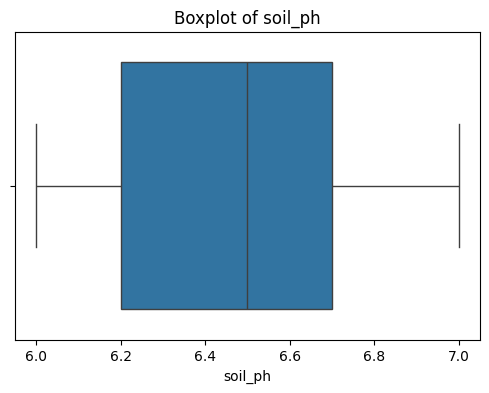

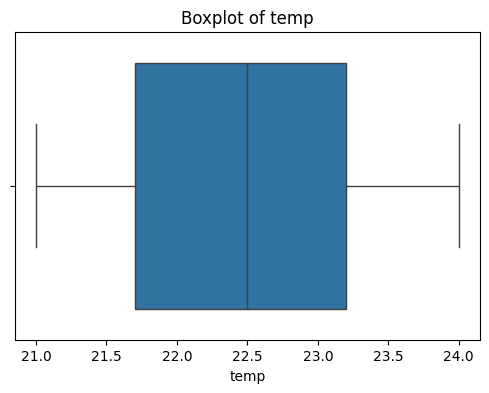

In [20]:
#plotting for outlier check
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [21]:
#splitting targeted and inout columns
X = dataset.drop(target_col, axis=1)
y = dataset[target_col]

In [23]:
#encoding of targeted column
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Arooj-22' 'Dilkash-20' 'Falak-24' 'Sawera-24' 'Subhani-21']


In [24]:
#splitiing before applying SMOTE technique to prevent data leak

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (799, 6)
Test Shape: (200, 6)


In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Convert to list
class_weights = [float(w) for w in weights]

print(class_weights)

[1.2682539682539682, 1.0945205479452054, 1.2106060606060607, 0.7573459715639811, 0.8684782608695653]


In [29]:
# Base model
model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.03,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_state=42,
    verbose=100,
    l2_leaf_reg=5,
    bagging_temperature=1,
    random_strength=2,
    class_weights=class_weights
)


In [30]:
trained_model=model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols
)


0:	learn: 0.6344960	total: 79.1ms	remaining: 1m 18s
100:	learn: 0.8154100	total: 2.44s	remaining: 21.7s
200:	learn: 0.8806459	total: 5.07s	remaining: 20.2s
300:	learn: 0.9283740	total: 8.82s	remaining: 20.5s
400:	learn: 0.9649323	total: 12.2s	remaining: 18.2s
500:	learn: 0.9772208	total: 15.3s	remaining: 15.3s
600:	learn: 0.9871841	total: 18.3s	remaining: 12.2s
700:	learn: 0.9907217	total: 22.1s	remaining: 9.43s
800:	learn: 0.9920974	total: 25.2s	remaining: 6.25s
900:	learn: 0.9955086	total: 28.2s	remaining: 3.1s
999:	learn: 0.9979652	total: 31.8s	remaining: 0us


In [31]:
y_pred = trained_model.predict(X_test)

In [32]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nMacro F1 Score:")
print(f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.85

Macro F1 Score:
0.8488257753116786

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.81        31
           1       0.89      0.86      0.88        37
           2       0.85      0.88      0.87        33
           3       0.81      0.91      0.86        53
           4       0.81      0.85      0.83        46

    accuracy                           0.85       200
   macro avg       0.86      0.84      0.85       200
weighted avg       0.86      0.85      0.85       200



In [33]:
import joblib

# Save model
joblib.dump(model, 'seed_recommender_model.pkl')

# Save label encoder
joblib.dump(label_encoder, 'label_encoder.pkl')

print("Model saved successfully.")

Model saved successfully.


In [ ]:
sample = pd.DataFrame({
    'soil_type': ['Clay'],
    'region': ['Punjab'],
    'irrigation_source': ['Canal'],
    'sown': ['November'],
    'soil_ph': [7.2],
    'temp': [24],
    'n': [110],
    'p': [45],
    'k': [60]
})

prediction = trained_model.predict(sample)

predicted_seed = label_encoder.inverse_transform(prediction)

print("Recommended Seed:", predicted_seed[0])

Recommended Seed: Sawera-24
